In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/content/Classification.csv')
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#Information
cp: نوع درد در قفسه سینه\
trtbps: فشارخون در حالت استراحت\
fbs: دیابت\
restecg: نتیجه نوار قلب در استراحت\
thalachh: حداکثر ضربان قلب\
exng: آیا درد با فعالیت خاصی شروع شد\
caa: تعداد رگ های اصلی


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
col = df.columns
col

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

#preprocess

In [9]:
cdf = df.copy()
cdf.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: >

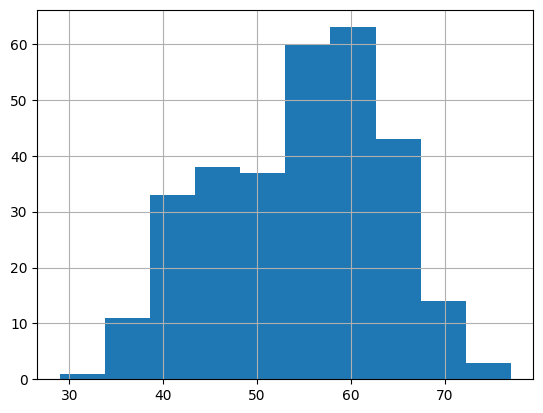

In [10]:
cdf['age'].hist()

In [11]:
for i in cdf[['oldpeak', 'slp', 'thall']]:
  print(cdf[i].value_counts())

oldpeak
0.0    99
1.2    17
1.0    14
0.6    14
0.8    13
1.4    13
0.2    12
1.6    11
1.8    10
2.0     9
0.4     9
0.1     7
2.8     6
2.6     6
1.9     5
1.5     5
3.0     5
0.5     5
2.2     4
3.6     4
0.9     3
3.4     3
4.0     3
2.4     3
0.3     3
3.2     2
2.3     2
1.1     2
4.2     2
2.5     2
1.3     1
3.5     1
0.7     1
3.1     1
6.2     1
5.6     1
2.9     1
2.1     1
3.8     1
4.4     1
Name: count, dtype: int64
slp
2    142
1    140
0     21
Name: count, dtype: int64
thall
2    166
3    117
1     18
0      2
Name: count, dtype: int64


In [12]:
cdf.shape

(303, 14)

In [13]:
cdf.drop(columns=['oldpeak', 'slp', 'thall'], inplace=True)
print(cdf.shape)
print(cdf.head())

(303, 11)
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  caa  output
0   63    1   3     145   233    1        0       150     0    0       1
1   37    1   2     130   250    0        1       187     0    0       1
2   41    0   1     130   204    0        0       172     0    0       1
3   56    1   1     120   236    0        1       178     0    0       1
4   57    0   0     120   354    0        1       163     1    0       1


In [15]:
cdf.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'caa', 'output'],
      dtype='object')

In [18]:
X = cdf[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'caa']].values
X[:5]

array([[ 63,   1,   3, 145, 233,   1,   0, 150,   0,   0],
       [ 37,   1,   2, 130, 250,   0,   1, 187,   0,   0],
       [ 41,   0,   1, 130, 204,   0,   0, 172,   0,   0],
       [ 56,   1,   1, 120, 236,   0,   1, 178,   0,   0],
       [ 57,   0,   0, 120, 354,   0,   1, 163,   1,   0]])

In [21]:
y = cdf['output'].values
y[:5]

array([1, 1, 1, 1, 1])

In [14]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X[0:5]

array([[ 0.9521966 ,  0.68100522,  1.97312292,  0.76395577, -0.25633371,
         2.394438  , -1.00583187,  0.01544279, -0.69663055, -0.71442887],
       [-1.91531289,  0.68100522,  1.00257707, -0.09273778,  0.07219949,
        -0.41763453,  0.89896224,  1.63347147, -0.69663055, -0.71442887],
       [-1.47415758, -1.46841752,  0.03203122, -0.09273778, -0.81677269,
        -0.41763453, -1.00583187,  0.97751389, -0.69663055, -0.71442887],
       [ 0.18017482,  0.68100522,  0.03203122, -0.66386682, -0.19835726,
        -0.41763453,  0.89896224,  1.23989692, -0.69663055, -0.71442887],
       [ 0.29046364, -1.46841752, -0.93851463, -0.66386682,  2.08204965,
        -0.41763453,  0.89896224,  0.58393935,  1.43548113, -0.71442887]])

#Model

In [25]:
from sklearn.model_selection import train_test_split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(212, 10)
(91, 10)
(212,)
(91,)


In [29]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
model = DecisionTreeClassifier(criterion='entropy')

In [51]:
model.fit(x_train, y_train)
model

DecisionTreeClassifier(criterion='entropy')

In [52]:
y_hat = model.predict(x_test)
print(y_hat[0:5])
print(y_test[0:5])

[1 1 1 1 1]
[1 0 1 1 0]


In [67]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score


In [69]:
print(accuracy_score(y_train, model.predict(x_train)))
print(accuracy_score(y_test,y_hat))

1.0
0.7142857142857143


In [70]:
f1_score(y_test, y_hat)

0.7719298245614035

In [55]:
confusion_matrix(y_test, y_hat)

array([[21, 17],
       [ 9, 44]])

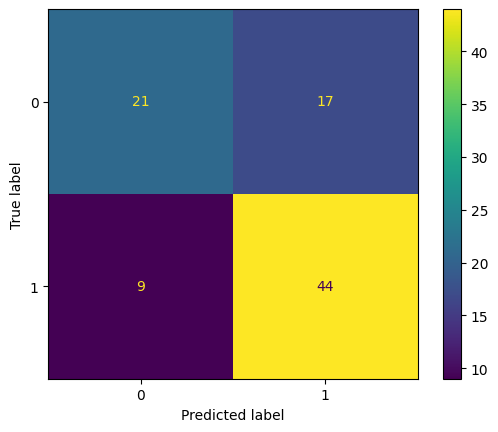

In [56]:
ConfusionMatrixDisplay.from_predictions(y_test, y_hat)

In [57]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



In [58]:
from sklearn.tree import plot_tree

[Text(0.5277777777777778, 0.9583333333333334, 'x[9] <= -0.225\nentropy = 0.998\nsamples = 212\nvalue = [100, 112]\nclass = 1'),
 Text(0.3402777777777778, 0.875, 'x[7] <= 0.387\nentropy = 0.766\nsamples = 112\nvalue = [25, 87]\nclass = 1'),
 Text(0.4340277777777778, 0.9166666666666667, 'True  '),
 Text(0.2361111111111111, 0.7916666666666666, 'x[4] <= 0.449\nentropy = 0.962\nsamples = 57\nvalue = [22, 35]\nclass = 1'),
 Text(0.16666666666666666, 0.7083333333333334, 'x[2] <= -0.453\nentropy = 0.854\nsamples = 43\nvalue = [12.0, 31.0]\nclass = 1'),
 Text(0.1111111111111111, 0.625, 'x[7] <= 0.147\nentropy = 0.998\nsamples = 19\nvalue = [9, 10]\nclass = 1'),
 Text(0.08333333333333333, 0.5416666666666666, 'x[7] <= -0.356\nentropy = 0.954\nsamples = 16\nvalue = [6, 10]\nclass = 1'),
 Text(0.05555555555555555, 0.4583333333333333, 'x[3] <= -0.949\nentropy = 1.0\nsamples = 12\nvalue = [6, 6]\nclass = 0'),
 Text(0.027777777777777776, 0.375, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = 1'),

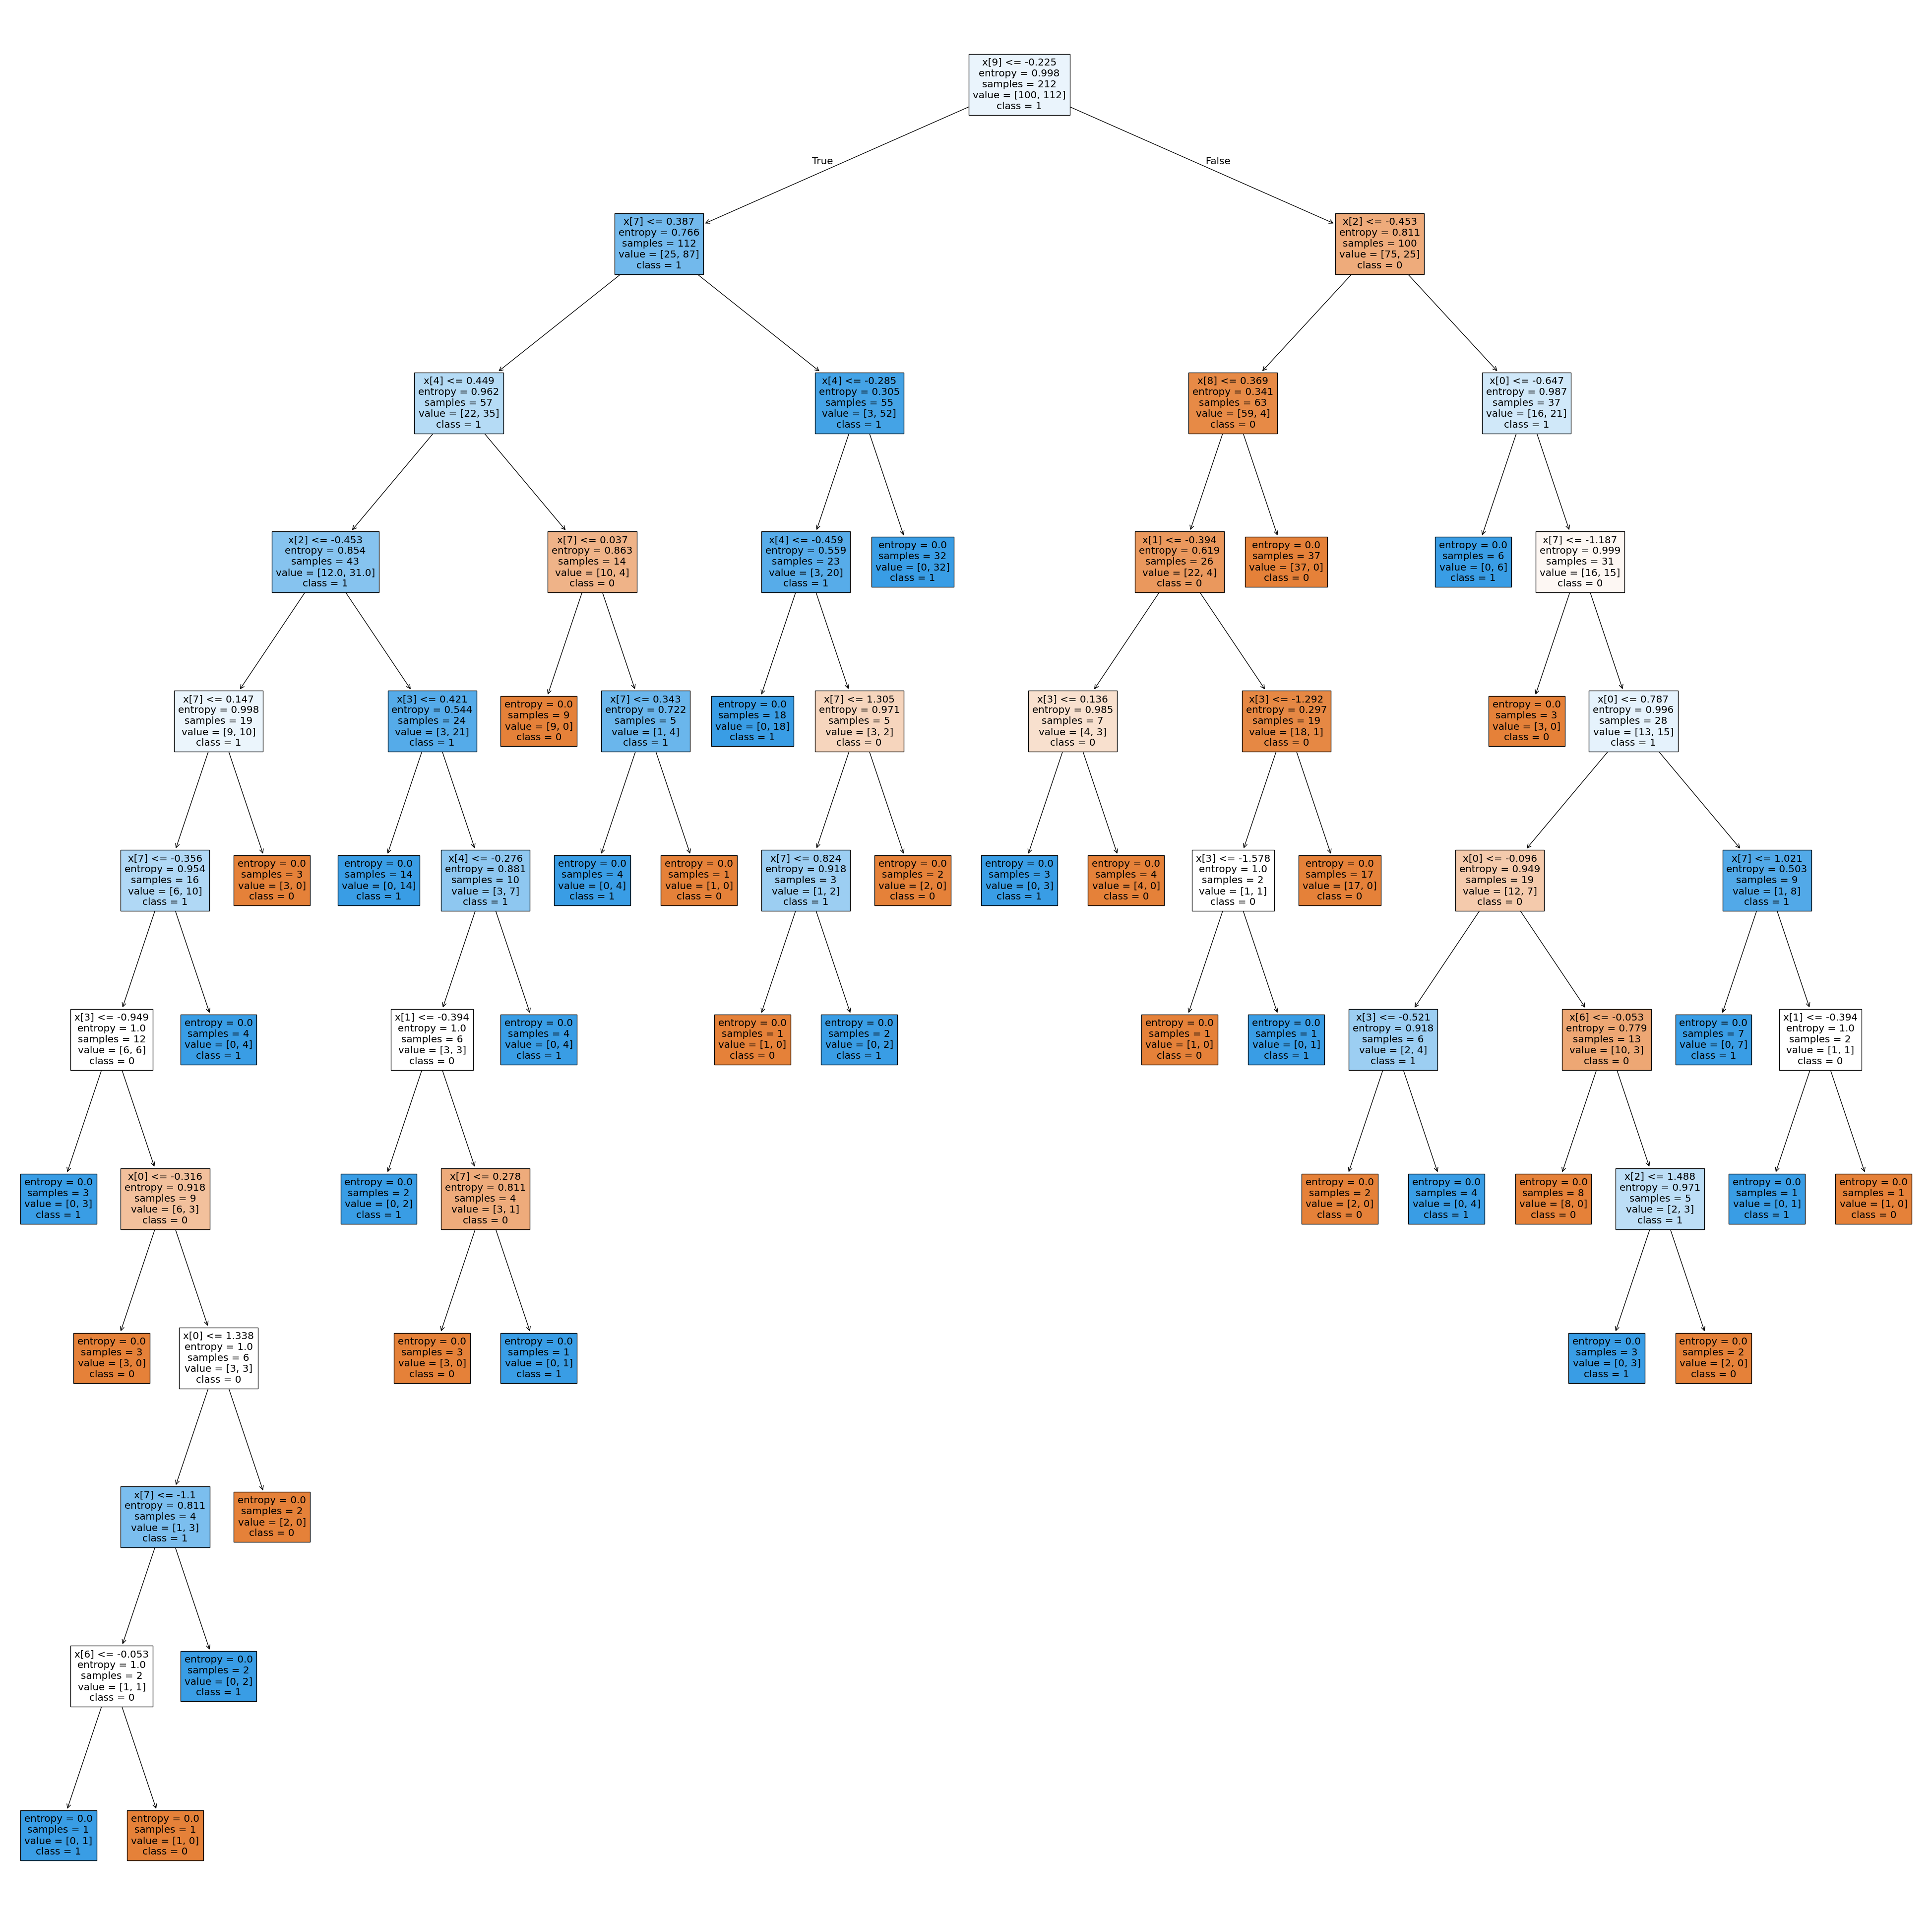

In [66]:
plt.figure(figsize=(50,50))
plot_tree(
    model,
    class_names=[str(c) for c in model.classes_],
    filled=True
)

#Model_2

In [73]:
from sklearn.linear_model import LogisticRegression

lbfgs
0.8392857142857143
[[26 12]
 [ 6 47]]
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        38
           1       0.80      0.89      0.84        53

    accuracy                           0.80        91
   macro avg       0.80      0.79      0.79        91
weighted avg       0.80      0.80      0.80        91



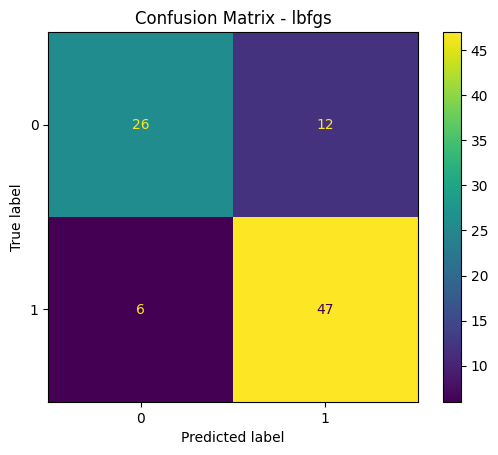

----------------------------------------
liblinear
0.8392857142857143
[[26 12]
 [ 6 47]]
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        38
           1       0.80      0.89      0.84        53

    accuracy                           0.80        91
   macro avg       0.80      0.79      0.79        91
weighted avg       0.80      0.80      0.80        91



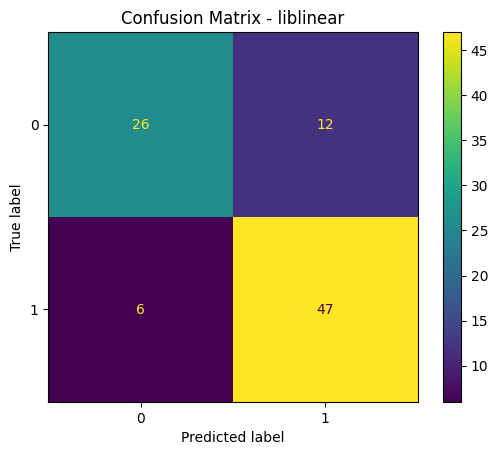

----------------------------------------
newton-cg
0.8392857142857143
[[26 12]
 [ 6 47]]
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        38
           1       0.80      0.89      0.84        53

    accuracy                           0.80        91
   macro avg       0.80      0.79      0.79        91
weighted avg       0.80      0.80      0.80        91



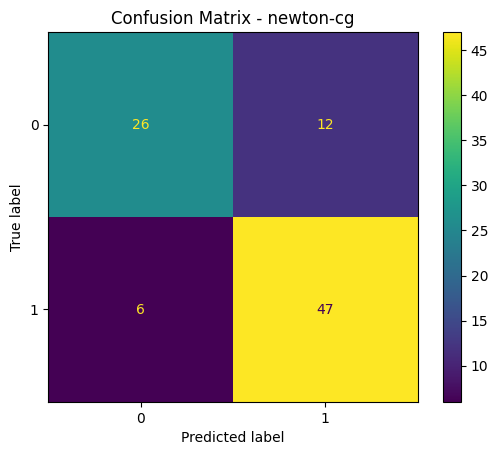

----------------------------------------
newton-cholesky
0.8392857142857143
[[26 12]
 [ 6 47]]
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        38
           1       0.80      0.89      0.84        53

    accuracy                           0.80        91
   macro avg       0.80      0.79      0.79        91
weighted avg       0.80      0.80      0.80        91



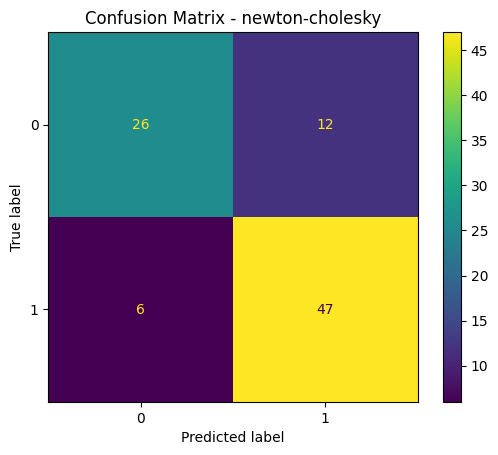

----------------------------------------
sag
0.8392857142857143
[[26 12]
 [ 6 47]]
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        38
           1       0.80      0.89      0.84        53

    accuracy                           0.80        91
   macro avg       0.80      0.79      0.79        91
weighted avg       0.80      0.80      0.80        91



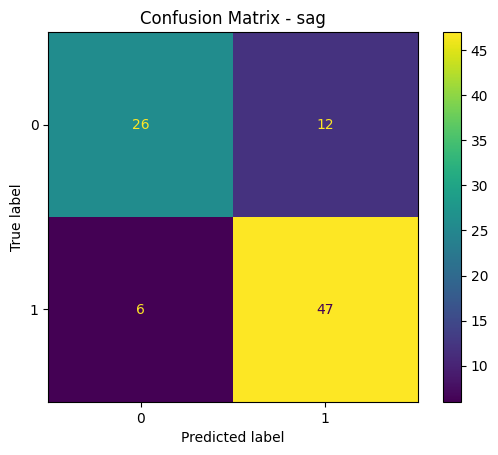

----------------------------------------
saga
0.8392857142857143
[[26 12]
 [ 6 47]]
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        38
           1       0.80      0.89      0.84        53

    accuracy                           0.80        91
   macro avg       0.80      0.79      0.79        91
weighted avg       0.80      0.80      0.80        91



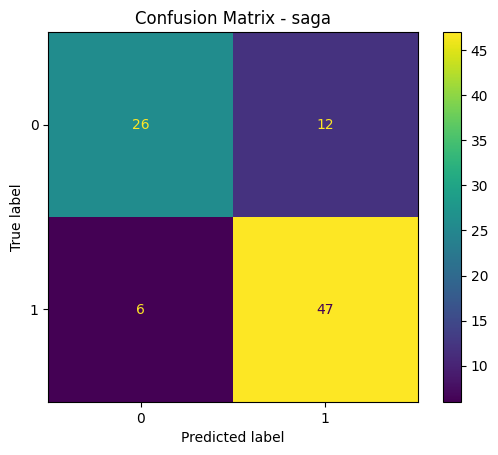

----------------------------------------


In [89]:
slover = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
for slo in slover:
  model_2 = LogisticRegression(solver=slo)
  model_2.fit(x_train, y_train)
  y_hat2 = model_2.predict(x_test)
  print(slo)
  print(f1_score(y_test, y_hat2))
  print(confusion_matrix(y_test, y_hat2))
  print(classification_report(y_test, y_hat2))
  ConfusionMatrixDisplay.from_predictions(y_test, y_hat2)
  plt.title(f"Confusion Matrix - {slo}")
  plt.show()
  print("-" * 40)

#Model_3

In [88]:
from sklearn import svm

linear
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



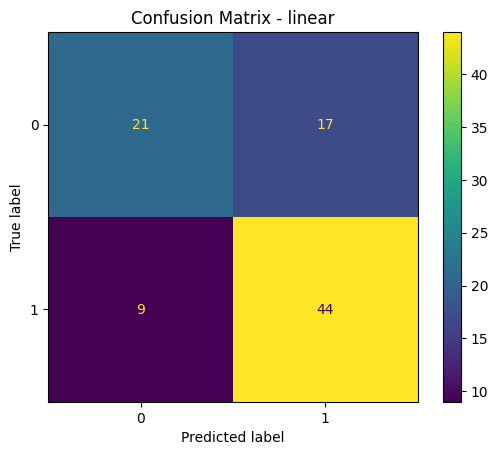

----------------------------------------
poly
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



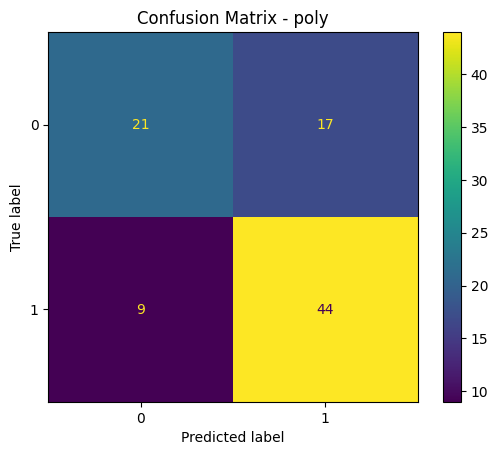

----------------------------------------
rbf
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



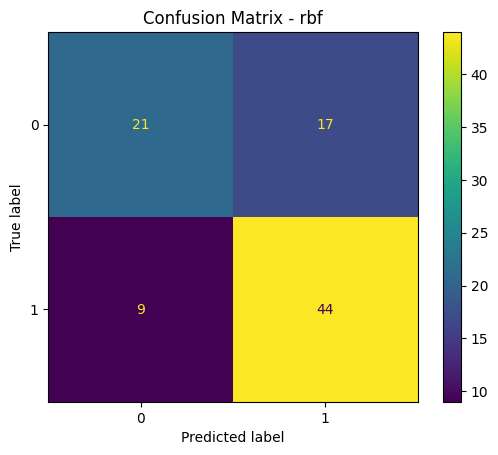

----------------------------------------
sigmoid
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



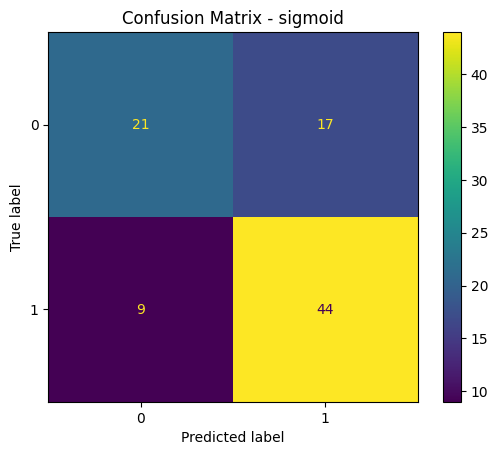

----------------------------------------


In [92]:
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
for ker in kernel:
  model_3 = svm.SVC(kernel=ker)
  model_3.fit(x_train, y_train)
  y_hat3 = model.predict(x_test)
  print(ker)
  print(f1_score(y_test, y_hat3))
  print(confusion_matrix(y_test, y_hat3))
  print(classification_report(y_test, y_hat3))
  ConfusionMatrixDisplay.from_predictions(y_test, y_hat3)
  plt.title(f"Confusion Matrix - {ker}")
  plt.show()
  print("-" * 40)

#Model_4

In [93]:
from sklearn.neighbors import KNeighborsClassifier

3
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



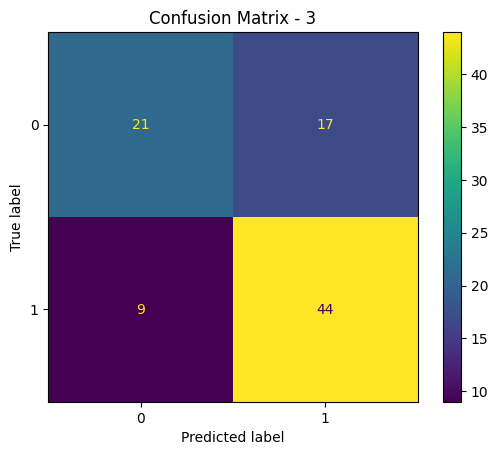

----------------------------------------
4
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



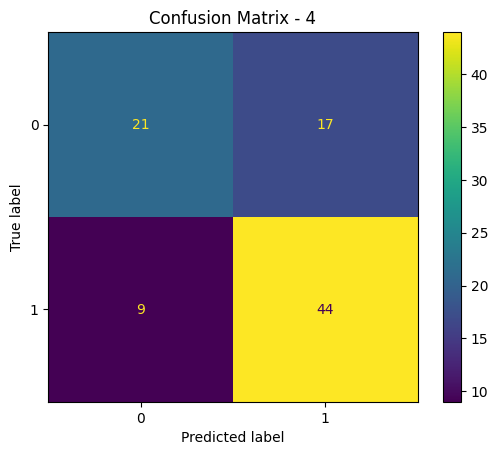

----------------------------------------
5
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



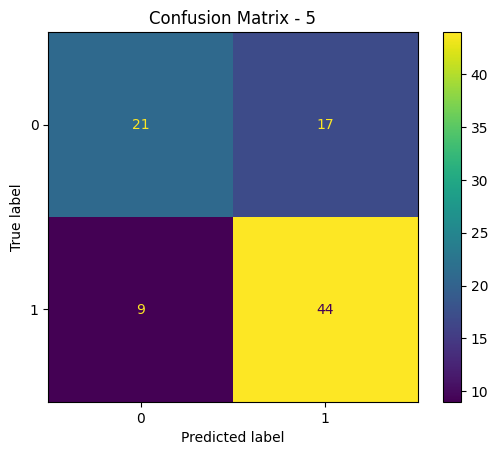

----------------------------------------
6
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



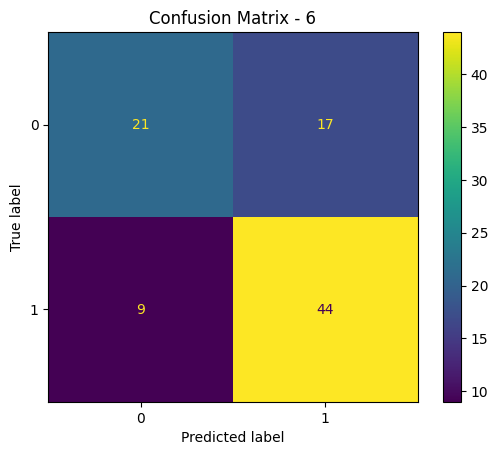

----------------------------------------
7
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



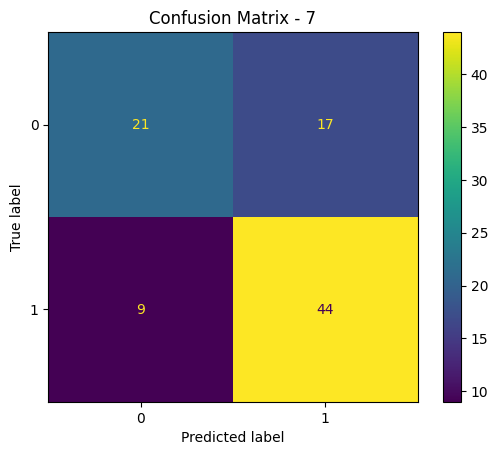

----------------------------------------
8
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



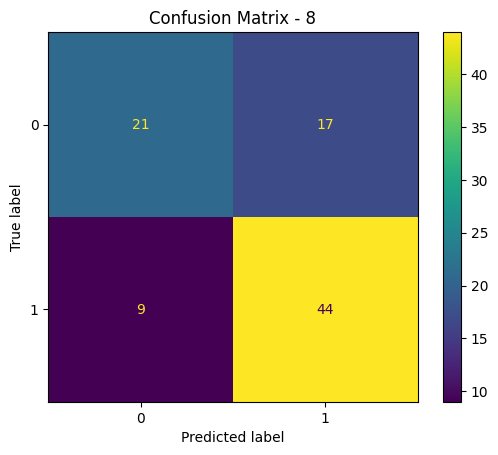

----------------------------------------
9
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



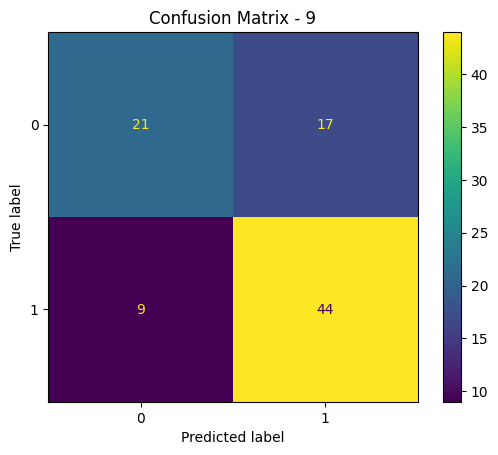

----------------------------------------
10
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



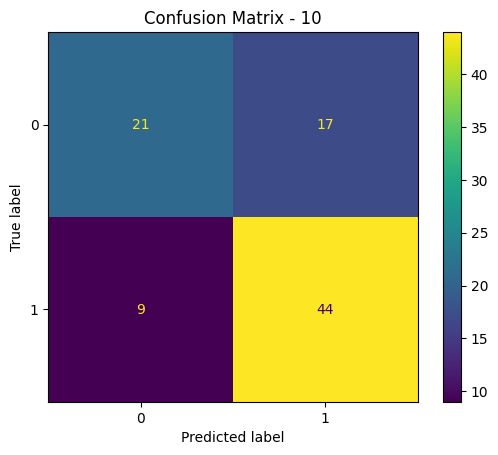

----------------------------------------
11
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



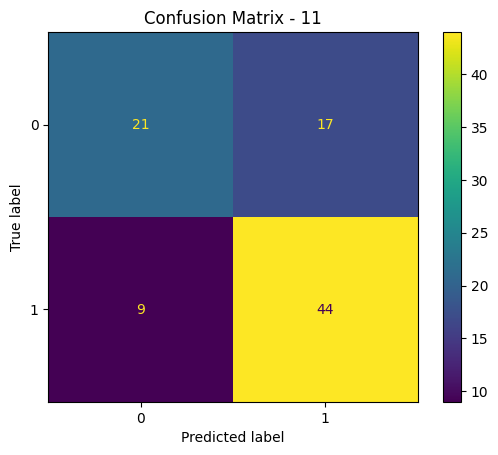

----------------------------------------
12
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



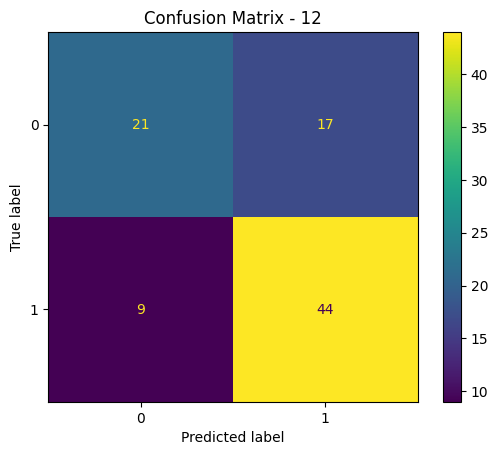

----------------------------------------
15
0.7719298245614035
[[21 17]
 [ 9 44]]
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.72      0.83      0.77        53

    accuracy                           0.71        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.71      0.71        91



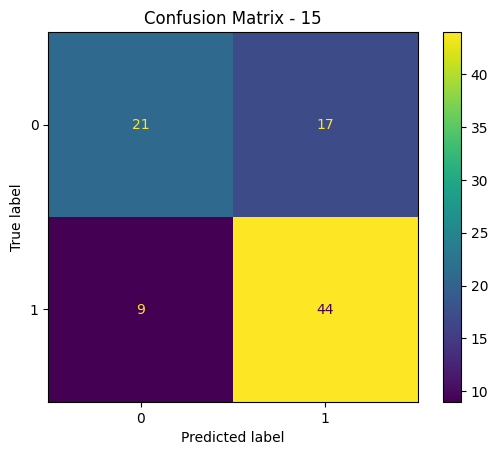

----------------------------------------


In [94]:
ks = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15]
for k in ks:
  model_4 = KNeighborsClassifier(n_neighbors=k)
  model_4.fit(x_train, y_train)
  y_hat4 = model.predict(x_test)
  print(k)
  print(f1_score(y_test, y_hat4))
  print(confusion_matrix(y_test, y_hat4))
  print(classification_report(y_test, y_hat4))
  ConfusionMatrixDisplay.from_predictions(y_test, y_hat4)
  plt.title(f"Confusion Matrix - {k}")
  plt.show()
  print("-" * 40)